 Exploring the relationship between trader performance and market
sentiment


Importing Necessary libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, precision_recall_curve, accuracy_score
from scipy import stats

#Importing Datasets
trades = pd.read_csv('/content/historical_data.csv')
sent  = pd.read_csv('/content/fear_greed_index.csv')

print(trades.shape); trades.head()


(211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [41]:
print(sent.shape); sent.head()

(2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


**Preprocessing **

In [42]:
#normalize datetime
# trades: suppose column 'time' is Epoch or ISO string
trades['timestamp'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
trades['date'] = trades['timestamp'].dt.date

# sentiment ensuring date
sent['date'] = pd.to_datetime(sent['date']).dt.date
sent.rename(columns={'classification':'sentiment'}, inplace=True)

# look for missing or null values
trades.isnull().sum().sort_values(ascending=False).head(20)

,0
timestamp,131999
date,131999
Coin,0
Account,0
Execution Price,0
Size Tokens,0
Timestamp IST,0
Start Position,0
Size USD,0
Side,0


Converting numerical Columns

In [43]:
for c in ['Execution Price','Size Tokens','Closed PnL']:
    trades[c] = pd.to_numeric(trades[c], errors='coerce')
trades = trades[trades['Size Tokens'] > 0]

Feature Engineering

In [44]:
trades['notional'] = trades['Size Tokens'] * trades['Execution Price']  # approximate volume
trades['profit_flag'] = (trades['Closed PnL'] > 0).astype(int)
trades['pnl_pct'] = trades['Closed PnL'] / trades['notional'].replace(0, np.nan)  # percent pnl relative to trade notional
trades['side'] = trades['Side'].str.lower()  # normalize 'Buy'/'Sell'


**Daily and AcCount Sentiments **

In [45]:
daily = trades.groupby('date').agg(
    trades_count = ('Account','count'),
    total_notional = ('notional','sum'),
    avg_pnl = ('Closed PnL','mean'),
    median_pnl = ('Closed PnL','median'),
    win_rate = ('profit_flag','mean'),
    sum_pnl = ('Closed PnL','sum')
).reset_index()


In [46]:
acc_day = trades.groupby(['Account','date']).agg(
    trades_count=('Account','count'),
    sum_pnl=('Closed PnL','sum'),
    win_rate=('profit_flag','mean'),
    total_notional=('notional','sum')
).reset_index()


In [47]:
# Merging sentiment based on date
daily = daily.merge(sent.rename(columns={'Date':'date'}), on='date', how='left')
acc_day = acc_day.merge(sent.rename(columns={'Date':'date'}), on='date', how='left')


**Performing EDA **

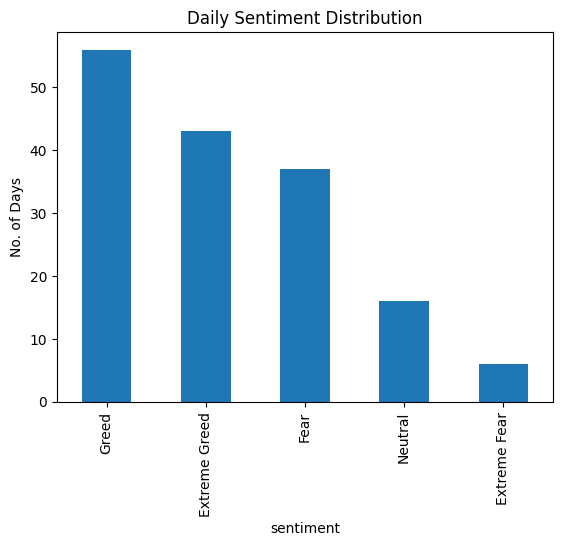

In [48]:
daily['sentiment'].value_counts().plot(kind='bar')
plt.ylabel("No. of Days")
plt.title('Daily Sentiment Distribution')
plt.show()

Text(0.5, 1.0, 'Daily sum PnL by Sentiment')

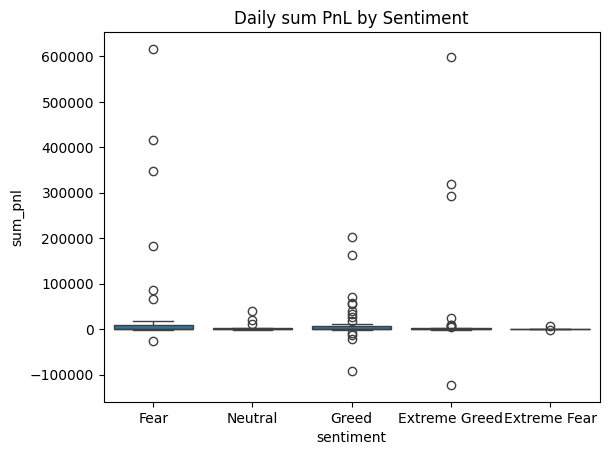

In [49]:
sns.boxplot(x='sentiment', y='sum_pnl', data=daily)
plt.title('Daily sum PnL by Sentiment')


Text(0.5, 1.0, 'Daily Win Rate by Sentiment')

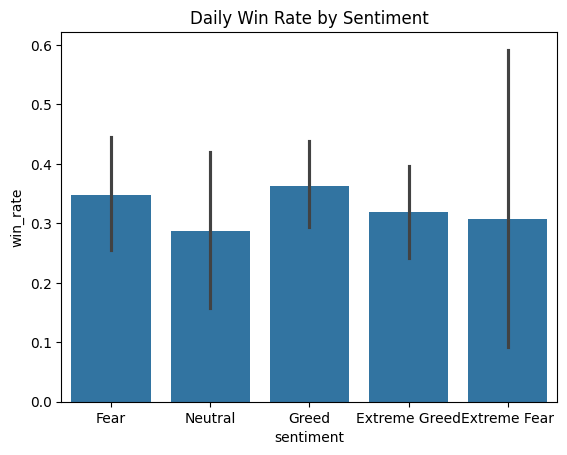

In [50]:
sns.barplot(x='sentiment', y='win_rate', data=daily)
plt.title('Daily Win Rate by Sentiment')

**Cumulative Pnl VS Sentiment**

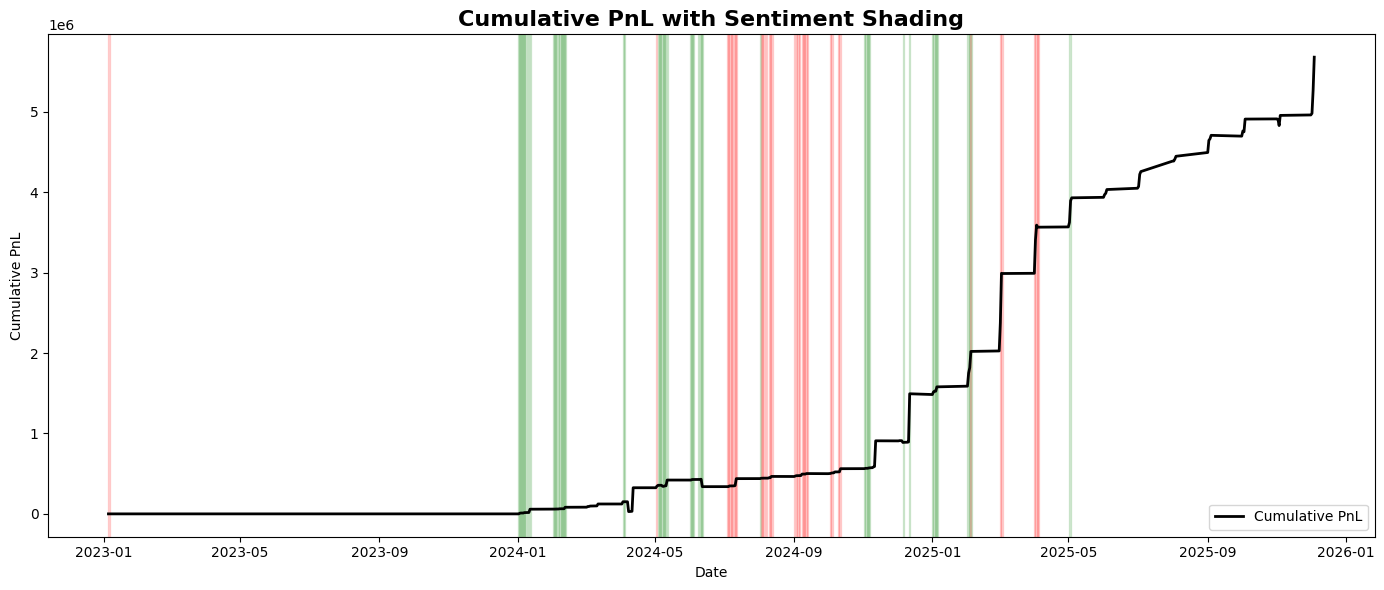

In [51]:
# Ensure daily is sorted by date
daily = daily.sort_values('date')

# Compute cumulative PnL
daily['cumulative_pnl'] = daily['sum_pnl'].cumsum()

# Set up plot
fig, ax = plt.subplots(figsize=(14,6))

# Plot cumulative PnL line
ax.plot(daily['date'], daily['cumulative_pnl'], color='black', linewidth=2, label='Cumulative PnL')

# Highlight sentiment background
for i in range(len(daily)):
    if daily['sentiment'].iloc[i] == 'Greed':
        ax.axvspan(daily['date'].iloc[i],
                   daily['date'].iloc[i] + pd.Timedelta(days=1),
                   color='green', alpha=0.15)
    elif daily['sentiment'].iloc[i] == 'Fear':
        ax.axvspan(daily['date'].iloc[i],
                   daily['date'].iloc[i] + pd.Timedelta(days=1),
                   color='red', alpha=0.15)

# plotting
ax.set_title("Cumulative PnL with Sentiment Shading", fontsize=16, weight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative PnL")
ax.legend()
plt.tight_layout()
plt.show()


**That plot shows how profits/losses accumulate over time, with the background shaded by market sentiment . We can see clearly if PnL grows faster during Greed and slows or drops during Fear, making sentiment's impact on performance .**